In [4]:
!git clone -b EDA https://github.com/RafaMazoliniF/SuperResLight.git

Cloning into 'SuperResLight'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 40 (delta 7), reused 37 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 19.79 MiB | 14.49 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import SuperResLight.RELLISUR_DataLoader as rel
import SuperResLight.srmodels as srm
import SuperResLight.utils as u
from torch.cuda.amp import autocast, GradScaler

SyntaxError: invalid syntax (ipython-input-3924772146.py, line 5)

In [2]:
device = 'cuda'

In [3]:
batch_size = 8

train_ds, val_ds, test_ds = rel.get_LLE_datasets_with_hist()
train_dl, val_dl, test_dl = rel.get_SR_dataloaders(train_ds, val_ds, test_ds, batch_size)

In [4]:
model = srm.SimpleLLE().to(device)
criterion = u.PSNRLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) 

In [5]:
u.training_loop(model, criterion, optimizer, 10, train_dl, device)

Epoch [1/10], Loss: -16.936299
Epoch [2/10], Loss: -17.750177
Epoch [3/10], Loss: -17.791920
Epoch [4/10], Loss: -17.823072
Epoch [5/10], Loss: -17.851174
Epoch [6/10], Loss: -17.864820
Epoch [7/10], Loss: -17.954659
Epoch [8/10], Loss: -17.901390
Epoch [9/10], Loss: -17.963806
Epoch [10/10], Loss: -17.904591


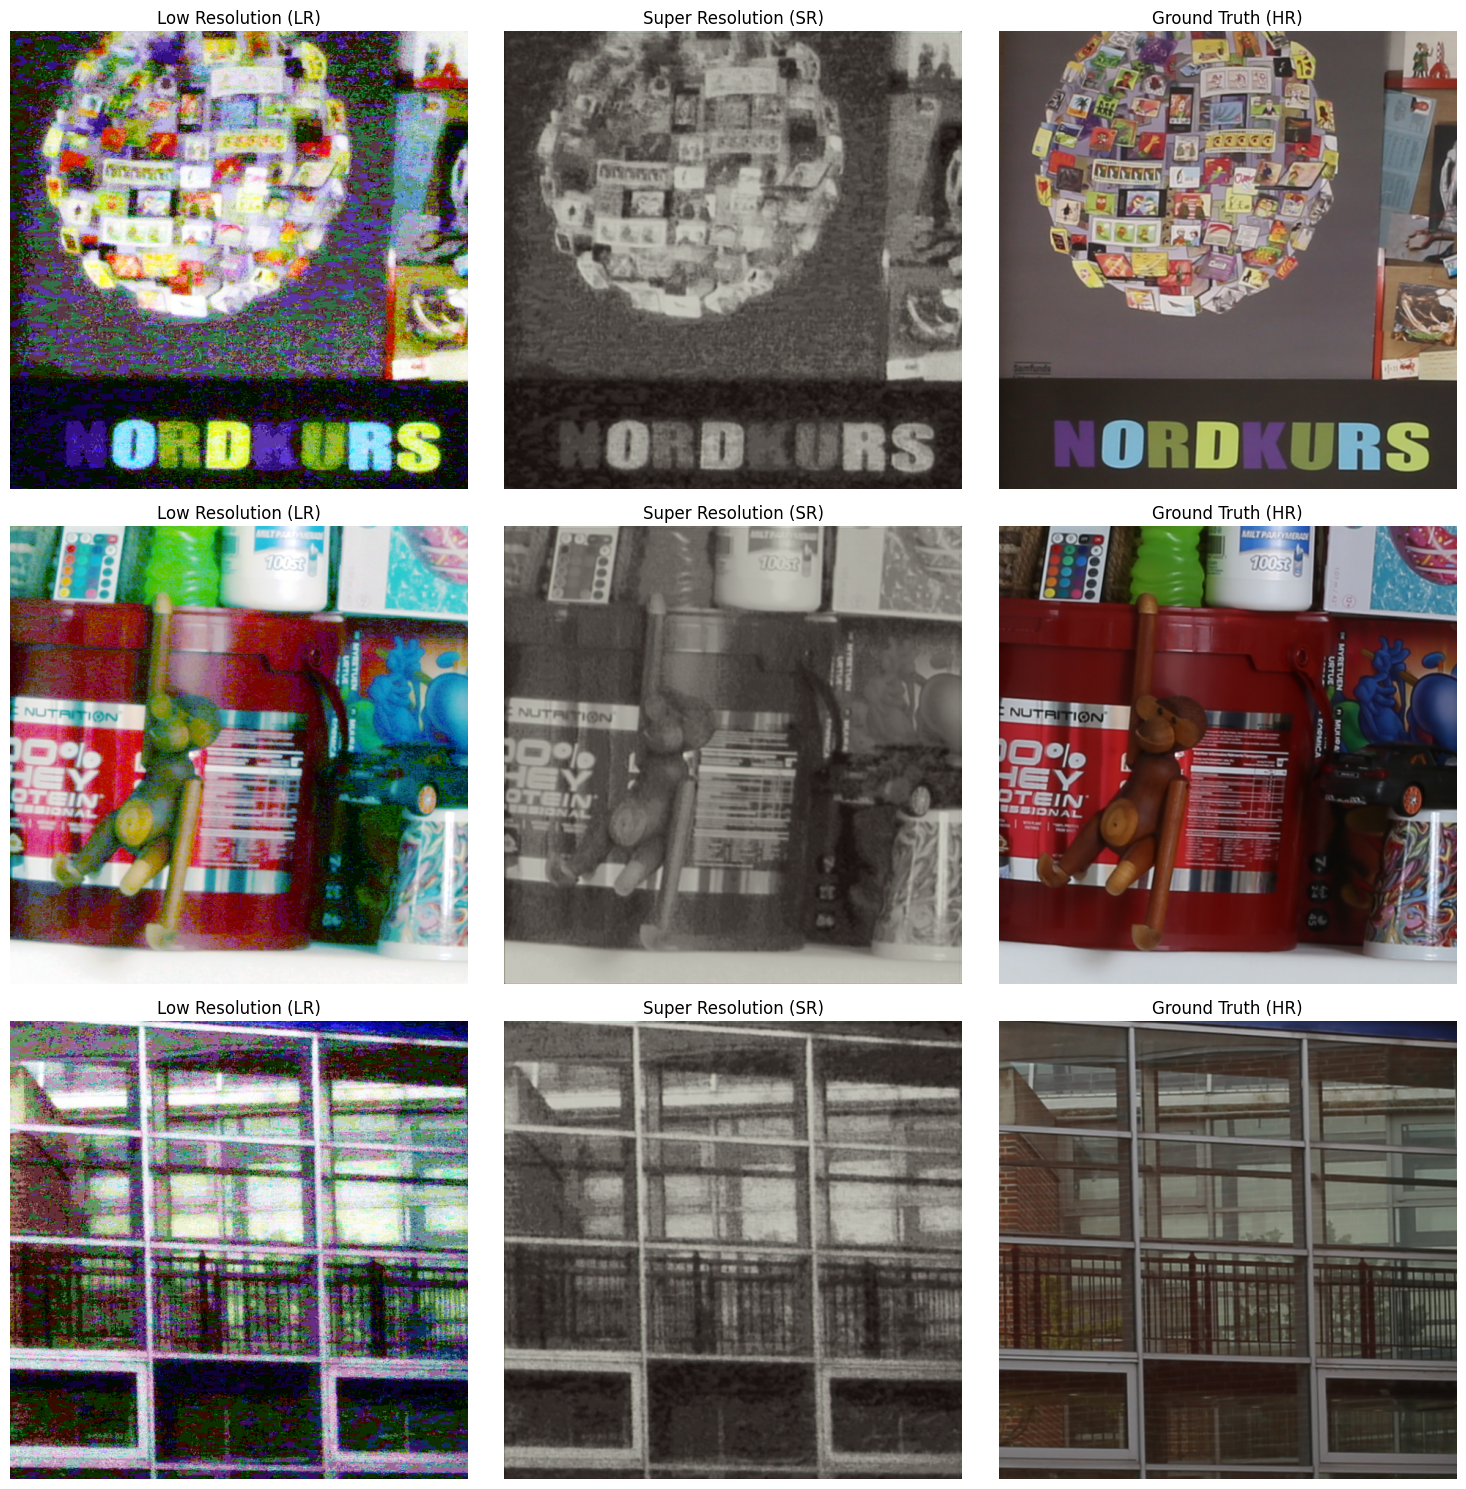

In [6]:
u.visualize_results(model, val_dl, device, num_samples=3)